# Conditional GAN Synthetic Dataset Framework

Notebook ini menjalankan framework Python yang sudah disamakan dengan `conditional_gan_image_dataset_gpu_rev.ipynb`: residual conditional generator, projection discriminator, spectral normalization, hinge loss, R1 penalty, classwise feature matching, dan EMA generator.

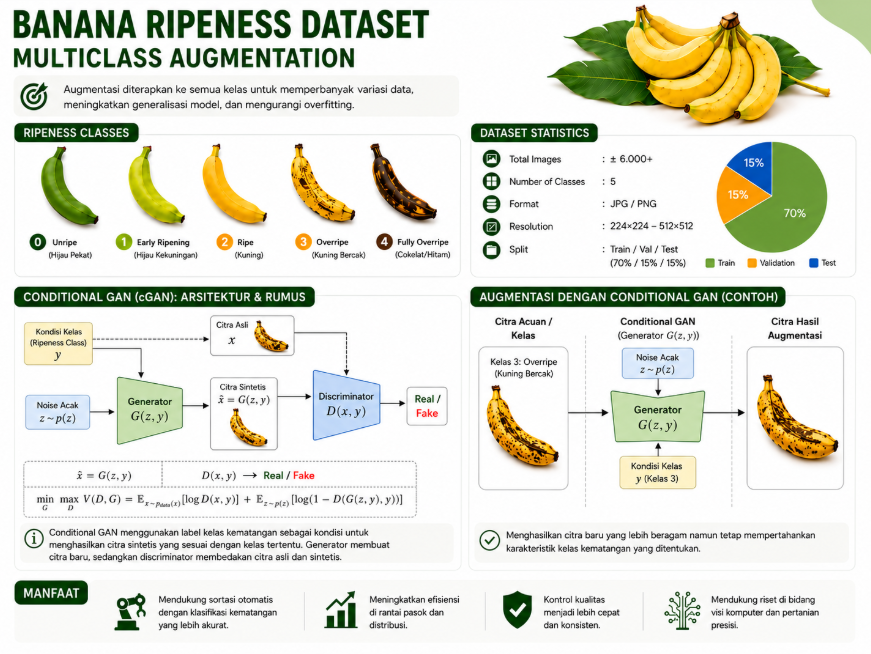

## 1. Cek CUDA

Jika berjalan di Windows + Jupyter, gunakan `NUM_WORKERS=0` di `.env` agar DataLoader tidak hang.

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(torch.version.cuda)

2.11.0+cu128
True
NVIDIA GeForce RTX 4070 SUPER
12.8


## 2. Load Konfigurasi

Ubah dataset, resolusi, epoch, batch size, dan output melalui `.env`. Default GAN utama mengikuti notebook contoh.

In [2]:
import json
from IPython.display import Markdown, display
from config import CONFIG

CONFIG.validate()
display(Markdown('## Ringkasan Konfigurasi'))
print(json.dumps(CONFIG.summary(), indent=4, default=str))

## Ringkasan Konfigurasi

{
    "dataset_path": "C:\\Users\\zendi\\Documents\\DeepLearning\\Pengolahan Citra Digital\\Augmentation GAN\\dataset\\retinal_oct",
    "output_dir": "C:\\Users\\zendi\\Documents\\DeepLearning\\Pengolahan Citra Digital\\Augmentation GAN\\outputs_retina_contour256",
    "synthetic_output_dir": "C:\\Users\\zendi\\Documents\\DeepLearning\\Pengolahan Citra Digital\\Augmentation GAN\\outputs_retina_contour256\\generate_synthetic_image",
    "model_name": "simple_cnn",
    "pretrained": false,
    "image_size": 256,
    "split_by_source": true,
    "crop_foreground": true,
    "crop_threshold": 18.0,
    "crop_margin_ratio": 0.03,
    "batch_size": 8,
    "epochs_classifier": 30,
    "epochs_gan": 30,
    "gan_latent_dim": 128,
    "gan_base_channels": 64,
    "gan_augment_train": true,
    "gan_exclude_augmented": true,
    "gan_excluded_augmentation_types": [
        "blur",
        "noise",
        "brightcontrast",
        "clahe",
        "rotate",
        "hflip"
    ],
    "gan_label

## 3. Verifikasi Model GAN

Cell ini memastikan arsitektur framework sudah bisa dibuat dan forward pass berjalan sebelum training penuh.

In [3]:
import torch
from src.data import prepare_data
from src.models import build_gan
from src.utils import get_device, set_seed

set_seed(CONFIG.seed)
device = get_device(CONFIG.device)
if CONFIG.gan_force_gpu and device.type != 'cuda':
    raise RuntimeError('CUDA tidak terdeteksi, padahal GAN_FORCE_GPU=true.')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

data = prepare_data(CONFIG)
gan = build_gan(CONFIG, num_classes=(1 if CONFIG.gan_per_class else len(data.class_names))).to(device)
labels = torch.zeros(2, dtype=torch.long, device=device) if CONFIG.gan_per_class else torch.arange(2, device=device) % len(data.class_names)
noise = gan.sample_noise(labels.size(0), device=device)
fake = gan.generate(labels=labels, noise=noise)
logits, _, features = gan.discriminate(fake, labels)
print('Device:', device)
print('Classes:', data.class_names)
print('Fake shape:', tuple(fake.shape))
print('Logits shape:', tuple(logits.shape))
print('Feature shape:', tuple(features.shape))

Mode dataset        : folder_lokal
Dataset aktif       : retinal_oct
Path dataset lokal  : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Folder kelas terbaca: C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Strategi split      : source_group
Data GAN bersih     : train=2646 (-1005), val=887 (-330)
Device: cuda
Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Fake shape: (2, 3, 256, 256)
Logits shape: (2,)
Feature shape: (2, 512)


## 4. Training Lengkap

Menjalankan pipeline penuh: persiapan dataset, training GAN, generate dataset sintetis, training classifier, dan evaluasi.

In [4]:
import train
train.main()


1. Menyiapkan Dataset
Mode dataset        : folder_lokal
Dataset aktif       : retinal_oct
Path dataset lokal  : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Folder kelas terbaca: C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Strategi split      : source_group
Data GAN bersih     : train=2646 (-1005), val=887 (-330)
Folder dataset : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Nama kelas     : ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total gambar   : 6086
Distribusi     : train=3651, val=1217, test=1218

2. Training GAN
GAN config              : latent_dim=128, base_channels=64, disc_steps=1, per_class=True
GAN detail pipeline      : exclude_augmented=True, edge_discriminator=False, spectral_norm=True, ema=0.995
GAN loss stabilizer     : loss_mode=hinge, label_smoothing=0.1, gp_weight=5.0, feature_match=1.


(process:34956): Pango-WARNING **: 15:36:36.719: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Graph classifier      : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\outputs_retina_contour256\classifier_assets\simple_cnn_architecture.png
Sampel train asli     : 3651
Sampel sintetis       : 400
Total train classifier: 4051
Model dilatih maksimal sebanyak: 30 epochs
Model terbaik akan disimpan di: C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\outputs_retina_contour256\best_model.pth
Early stopping       : aktif
Monitor              : val_loss
Patience             : 5
Minimum delta        : 0.001

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   Early Stop
----------------------------------------------------------------------------------
    1 |     0.9755 |    55.49% |   0.7833 |  61.63% |          0/5 *best
    2 |     0.8612 |    58.45% |   0.7438 |  61.30% |          0/5
    3 |     0.8224 |    61.00% |   0.6854 |  66.23% |          0/5 *best
    4 |     0.7861 |    62.92% |   0.7045 |  66.72% |          

## 5. Evaluasi Ulang dari Checkpoint

Jalankan cell ini jika checkpoint dan gambar sintetis sudah ada.

In [5]:
import evaluate
evaluate.main()


1. Menyiapkan Dataset
Mode dataset        : folder_lokal
Dataset aktif       : retinal_oct
Path dataset lokal  : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Folder kelas terbaca: C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Strategi split      : source_group
Data GAN bersih     : train=2646 (-1005), val=887 (-330)
Folder dataset : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\dataset\retinal_oct
Nama kelas     : ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Jumlah test    : 1218

2. Memuat GAN dan Classifier
GAN per kelas dimuat dari : C:\Users\zendi\Documents\DeepLearning\Pengolahan Citra Digital\Augmentation GAN\outputs_retina_contour256\classwise_gans
Best val loss cataract  : -0.167581
Best val loss diabetic_retinopathy: -0.059205
Best val loss glaucoma  : 0.258838
Best val loss normal    : -0.177189
Classifier dimuat dari  :